# Analisis exploratorio de datos

In [1]:
import pandas as pd

In [ ]:
data = pd.read_csv('../data_project/raw/dataset_tickets.csv', encoding='latin-1')

In [5]:
data.head(5)

,short_description,close_notes,etiqueta
0,VINCULACION PREVENTAS FIDUCIARIA (ONE ID) - Se...,"Cerrado por sistemas, sin respuesta",2
1,VINCULACION PREVENTAS FIDUCIARIA (ONE ID) - Se...,"Cerrado por sistemas, sin respuesta",2
2,Se presenta inconveniente para la vinculaciÃ³n...,SoluciÃ³n Temporal,2
3,VINCULACION PREVENTAS FIDUCIARIA (ONE ID) - Pr...,Buen dÃ­a.\r\n\r\nse identificÃ³ que a veces l...,2
4,VINCULACION PREVENTAS FIDUCIARIA (ONE ID): La...,"Cerrado por sistemas, sin respuesta",0


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

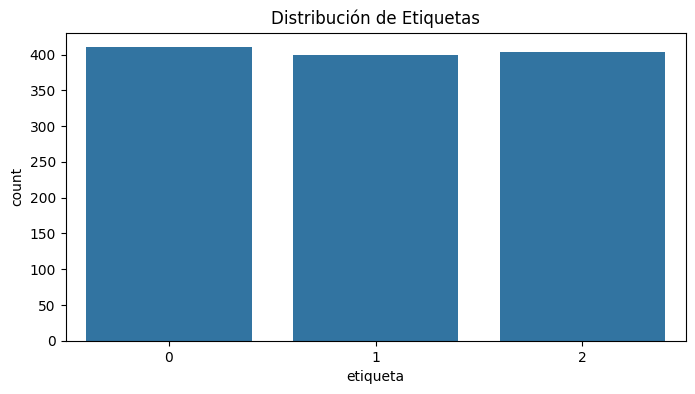

In [9]:
plt.figure(figsize=(8, 4))
sns.countplot(x='etiqueta', data=data)
plt.title('Distribución de Etiquetas')
plt.show()

In [13]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:992)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:992)>


In [18]:
stopwords_es = set(stopwords.words('spanish'))
stemmer = SnowballStemmer("spanish")

In [17]:
stopwords_personalizadas = {
    "buen", "buenos", "dia", "tardes","buenas", "grupo", "asignación", "asignacin", "asignanar" ,"asignado", "davinci", "preventa", "fiduciaria",
    "respuesta", "proveedor", "favor", "pronta", "quedo", "atento",
    "sebastian", "sebastin", "prado", "vanegas", "identificación", "one", "id", "vinculacion", "preventas", "muchas", "gracias", "cliente",
    "atentos", "soporte", "cc"
}
stopwords_totales = stopwords_es.union(stopwords_personalizadas)

In [19]:
def limpiar_y_stem(texto):
    # Tokenizar en palabras
    tokens = word_tokenize(texto, language="spanish")

    # Filtrar stopwords y palabras no alfabéticas
    tokens_filtrados = [
        t for t in tokens
        if t.isalpha() and t.lower() not in stopwords_totales
    ]

    # Aplicar stemming
    tokens_stem = [stemmer.stem(t.lower()) for t in tokens_filtrados]

    # Volver a unir en un solo string
    return " ".join(tokens_stem)

In [22]:
import re
import string

In [21]:
def clean(text):
    # Convertir a minúsculas
    text = str(text).lower()

    # Eliminar textos entre corchetes (ej.: etiquetas)
    text = re.sub(r'\[.*?\]', '', text)

    # Eliminar URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Eliminar etiquetas HTML
    text = re.sub(r'<.*?>+', '', text)

    # Eliminar signos de puntuación
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)

    # Eliminar saltos de línea
    text = re.sub(r'\n', ' ', text)

    # Eliminar palabras que contienen números
    text = re.sub(r'\w*\d\w*', '', text)

    # Eliminar emojis y caracteres especiales (no ASCII)
    text = re.sub(r'[^\x00-\x7F]+', '', text)

    # Eliminar espacios extras al inicio y final
    text = text.strip()

    return text

In [23]:
data["clean_short_description"] = data["short_description"].apply(clean)
data["clean_close_notes"] = data["close_notes"].apply(clean)

In [24]:
data["clean_short_description_stem"] = data["clean_short_description"].apply(limpiar_y_stem)
data["clean_close_notes_stem"] = data["clean_close_notes"].apply(limpiar_y_stem)

In [14]:
def generar_nubes_de_palabras_de_categoría(df: pd.DataFrame,
                                 name_column_text: str,
                                 name_column_target: str):
    unique_categories = df[name_column_target].unique()[:10]
    for category in unique_categories:
        filtered_text = ' '.join(df[df[name_column_target] == category][name_column_text])
        print(f"Tokens unicos: {len(set(filtered_text.split()))}")
        if filtered_text:
            wordcloud = WordCloud(width=800, height=600, background_color='white',
                                  colormap='viridis', max_words=150, contour_color='steelblue',
                                  contour_width=2, prefer_horizontal=0.8).generate(filtered_text)
            plt.figure(figsize=(8, 8))  # Tamaño de la figura para mejorar la resolución
            plt.imshow(wordcloud, interpolation='bilinear')
            plt.axis('off')
            plt.title(f"Nube de palabras para categoría: {category}")
            plt.show()

Tokens unicos: 595


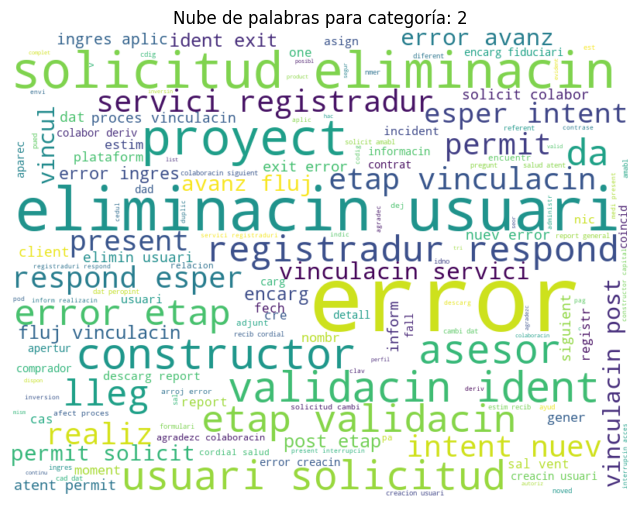

Tokens unicos: 367


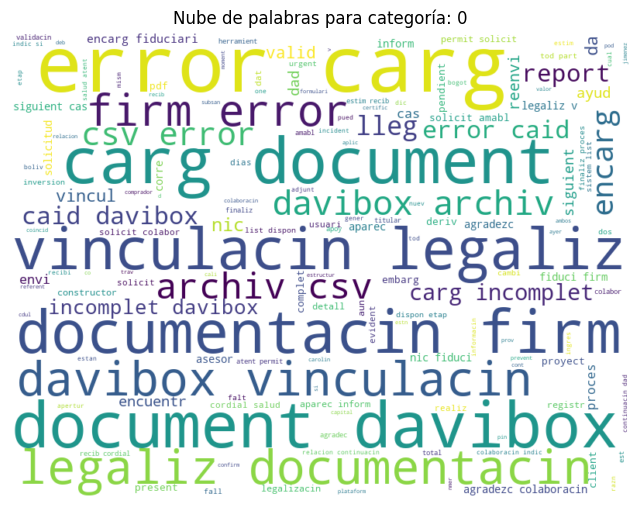

Tokens unicos: 564


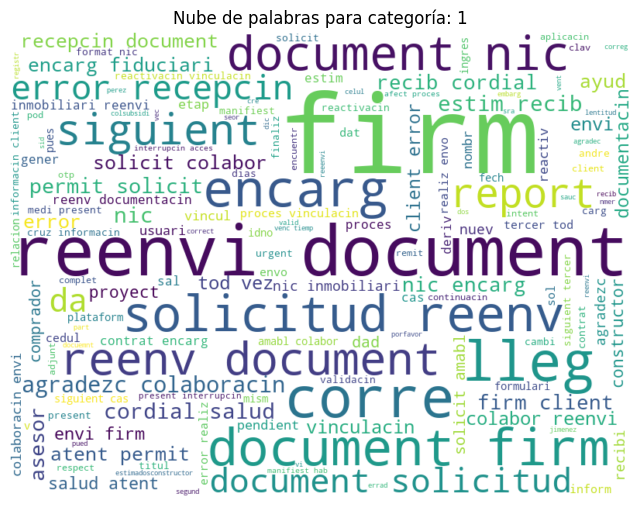

In [25]:
generar_nubes_de_palabras_de_categoría(df = data,
                             name_column_target = "etiqueta",
                             name_column_text= "clean_short_description_stem")

In [26]:
data.head(4)

,short_description,close_notes,etiqueta,clean_short_description,clean_close_notes,clean_short_description_stem,clean_close_notes_stem
0,VINCULACION PREVENTAS FIDUCIARIA (ONE ID) - Se...,"Cerrado por sistemas, sin respuesta",2,vinculacion preventas fiduciaria one id se ge...,cerrado por sistemas sin respuesta,gener vinculacin,cerr sistem
1,VINCULACION PREVENTAS FIDUCIARIA (ONE ID) - Se...,"Cerrado por sistemas, sin respuesta",2,vinculacion preventas fiduciaria one id se ge...,cerrado por sistemas sin respuesta,gener vinculacin,cerr sistem
2,Se presenta inconveniente para la vinculaciÃ³n...,SoluciÃ³n Temporal,2,se presenta inconveniente para la vinculacin y...,solucin temporal,present inconvenient vinculacin apertur produc...,solucin temporal
3,VINCULACION PREVENTAS FIDUCIARIA (ONE ID) - Pr...,Buen dÃ­a.\r\n\r\nse identificÃ³ que a veces l...,2,vinculacion preventas fiduciaria one id probl...,buen da\r \r se identific que a veces la base ...,problem vinculacin apertur product vinculacin,da identific vec bas dat usa clust kubernet pi...
